---
title: Splits Testing
author: Fedor Pavlov
date: 2026-03-23
format:
  html:
    code-fold: true
    code-summary: "Show the code"
  pdf:
    code-overflow: wrap
    echo: false
    output: true
---

A clone of Fedor Pavlov's code on `splits_testing.py` (deprecated, check previous versions of the branch), made by Andrei Akopian for some testing and image exports.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic
from sklearn.ensemble import RandomForestRegressor

## Loading the Data

In [2]:
LAB_DATA = "../../../data/useful_columns_data.csv"
ATMO_DATA = "../../../data/isprs_26_only_vza_rows.csv"

In [3]:
#getting the data to train on
file = pd.read_csv(ATMO_DATA)
#getting y's
y = []
for i in range(len(file["Spectra"])):
    y.append([file.loc[i,"npv_fraction"], file.loc[i,"soil_fraction"]])  # use for atmo data
    # y.append([file.loc[i,"gv_fraction"], file.loc[i,"npv_fraction"], file.loc[i,"soil_fraction"]]) # use for lab data

#getting x's
x = []
for i in range(len(file["Spectra"])):
    newAr = []
    for j in range(900,1700,10):
        newAr.append(file.loc[i,str(j)])
    x.append(newAr)
print("number of rows:", len(x))

number of rows: 144


## Performing the Splits

In [10]:
#spliting the data
def k_split_dataset(X: int, Y: int, train_size_percentage: int) -> list[list[list]]:
    
    kfold = KFold(n_splits=train_size_percentage, shuffle= True, random_state=44)

    ids = range(len(X))
    train_ids = np.array([])
    test_ids = np.array([])
    data = []
    for train, test  in kfold.split(ids):
        train_ids = np.array([])
        test_ids = np.array([])
        x_train = []
        x_test = [] 
        y_train = []  
        y_test = []
        train_ids = np.append(train,train_ids)
        test_ids = np.append(test,test_ids)
        for i in train_ids.astype(int):

            x_train.append(x[i])
            y_train.append(y[i])
        for i in test_ids.astype(int):
            x_test.append(x[i])
            y_test.append(y[i])
        data.append([x_train, x_test, y_train, y_test])
    return data

def get_all_splits(first: int, last: int) -> list:
    ar = []
    for k in range(first, last):
        ar.append(k_split_dataset(x,y,k))
    return ar

def find_the_most_optimal_k_splits(all_splits: list[int]) -> list[float]:
    r2s = []
    splitnum = 2
    for i in all_splits:
        bestr2 = -1
        bestrmse = -1
        best_y_test = []
        best_y_predict = []
        for j in i:
                #splitting the dataset
            X_train, X_test, y_train, y_test = j[0], j[1], j[2], j[3]
                #choosing regression type and training
            regr = RandomForestRegressor(random_state=42)
            regr.fit(X_train, y_train)
            y_predict = regr.predict(X_test)
                #getting results
            r2 = r2_score(y_test,y_predict)
            if r2> bestr2:
                bestr2 = r2
                best_y_test = y_test
                best_y_predict = y_predict
            print(f"train_size: {str(round(splitnum/len(all_splits), 2))}, r2: {str(r2)}")
        # print(len(X_train), len(X_test))
        r2s.append(bestr2)
        splitnum+=1
    return r2s

def find_the_most_optimal_randomsplit() -> list[float]:
    r2s = []
    for i in range(10,100,5):
        X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=1-i/100, train_size=i/100, random_state=42)
        regr = RandomForestRegressor(random_state=42)
        regr.fit(X_train, y_train)
        y_predict = regr.predict(X_test)
        rmse = root_mean_squared_error(y_test, y_predict)
        r2 = r2_score(y_test,y_predict)
        r2s.append(r2)
        print("train_size: "+str(i)+"%, r2: "+str(r2)+", rmse: "+str(rmse))
    return r2s

In [11]:
#orig_scores = cross_validation_scores(x,y,len(x)//10)
all_splits = get_all_splits(2, 20)

## Visualization

In [15]:
def create_r2s_plot(r2s: list[float]) -> None:
    """
    Create a graph of r^2s vs split size.
    """
    plt.rcParams["font.family"] = "Times New Roman"
    csfont = {'fontname':'Times New Roman'}
    plt.figure(figsize=(3, 5))  # change plot dimensions here
    plt.plot(range(10,100,5),r2s)
    plt.title("R^2 vs Train Size", **csfont)
    plt.xlabel("Train Size (%)", **csfont)
    plt.ylabel("R^2", **csfont)
    plt.xticks(range(0,100+1, 10))
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("splits_testing.svg", format='svg')
    plt.show()

train_size: 0.11, r2: -0.23798902882368267
train_size: 0.11, r2: 0.04188143225705687
train_size: 0.17, r2: -0.21585902160101667
train_size: 0.17, r2: -0.10037375986166652
train_size: 0.17, r2: -0.12497832318329494
train_size: 0.22, r2: -0.30003887640449467
train_size: 0.22, r2: 0.008771400491400516
train_size: 0.22, r2: 0.12999265532702298
train_size: 0.22, r2: -0.30725020674446324
train_size: 0.28, r2: -0.6000666854058927
train_size: 0.28, r2: -0.3199404880478083
train_size: 0.28, r2: -0.1533598668846332
train_size: 0.28, r2: 0.16522812054571334
train_size: 0.28, r2: -0.5064245317220541
train_size: 0.33, r2: -0.32605886513916726
train_size: 0.33, r2: -0.6420883324987484
train_size: 0.33, r2: -0.021799089068826327
train_size: 0.33, r2: 0.2746464937238488
train_size: 0.33, r2: 0.03832415143603213
train_size: 0.33, r2: -0.2612077645585469
train_size: 0.39, r2: -0.2642405816135086
train_size: 0.39, r2: -0.48285678617157435
train_size: 0.39, r2: -0.24498500000000023
train_size: 0.39, r2: -

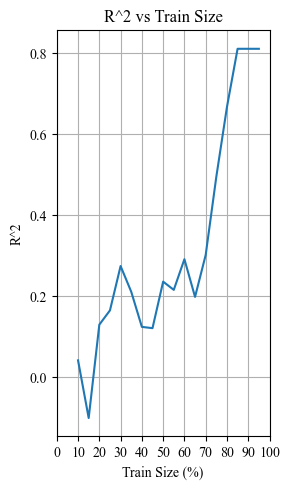

In [14]:
# takes <2 minutes to run
r2s = find_the_most_optimal_k_splits(all_splits)
create_r2s_plot(r2s)

train_size: 10%, r2: -0.41363445639420093, rmse: 0.3933161773746604
train_size: 15%, r2: -0.22404047438051078, rmse: 0.3632818677654508
train_size: 20%, r2: -0.31869610259465864, rmse: 0.38044070406614594
train_size: 25%, r2: -0.36074938026432757, rmse: 0.39156838010275585
train_size: 30%, r2: -0.32902175117761046, rmse: 0.38789403472883904
train_size: 35%, r2: -0.1787298837396203, rmse: 0.352840389447597
train_size: 40%, r2: -0.24030710452523696, rmse: 0.3682074939768196
train_size: 45%, r2: -0.34477621195039465, rmse: 0.38613736221712613
train_size: 50%, r2: -0.33333288111888126, rmse: 0.38356132712601076
train_size: 55%, r2: -0.2533851665132627, rmse: 0.3765832832598511
train_size: 60%, r2: -0.3898398686178163, rmse: 0.3933405342220261
train_size: 65%, r2: -0.2315220025130601, rmse: 0.3784043899757785
train_size: 70%, r2: -0.13520263606617777, rmse: 0.3567006320559173
train_size: 75%, r2: -0.19449511477339565, rmse: 0.37541155194444037
train_size: 80%, r2: -0.05106537995149529, rmse

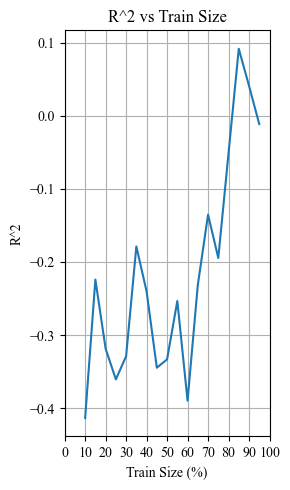

In [16]:
# takes <1 minute to run
r2s = find_the_most_optimal_randomsplit()
create_r2s_plot(r2s)